# Load libraries and data 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.stats import ks_2samp
from gwpy.timeseries import TimeSeries
from gwpy.segments import Segment

Load data in from Fermi_without_T90.ipynb 

# Configuration (edit this cell for each new GRB!!)
Use catalog from Fermi for T90: https://heasarc.gsfc.nasa.gov/db-perl/W3Browse/w3table.pl?tablehead=name%3Dfermigbrst&Action=More+Options
 Use MacLaughlan et al. for catalog MVT: https://arxiv.org/abs/1201.4431

In [12]:
GRB_name = 'GRB100414097'
Cataloug_T90  = 34.305 #seconds
Cataloug_tau_beta = 0.0025 #seconds
Q_fixed = 10 # Quality factor
Mismatch = 0.2
P_threshold = 0.05 # KS p-value threshold # 0.01

signal = np.load(f'{GRB_name}_signal.npy')
time = np.load(f'{GRB_name}_time.npy')
Tbin = float(np.load(f'{GRB_name}_Tbin.npy')[0])
fs = 1/Tbin

Pre_burst_lead = 20 # seconds of pre-burst background to use
Pre_burst_offset = 2 # seconds of gap between pre-burst end and burst start

print(f"{GRB_name}: Tbin = {Tbin*1e3:.3f}ms N = {len(signal)} Time Span = {time[-1]-time[0]:.3f}s")
#assert Tbin <= Cataloug_tau_beta/4, f"Binning is too coarse for catalog MVT"

GRB211211549: Tbin = 0.500ms N = 1227999 Time Span = 613.999s


# Windows

Burst:[3.910, 38.215] seconds
Pre-burst:[-16.090, 1.910] seconds


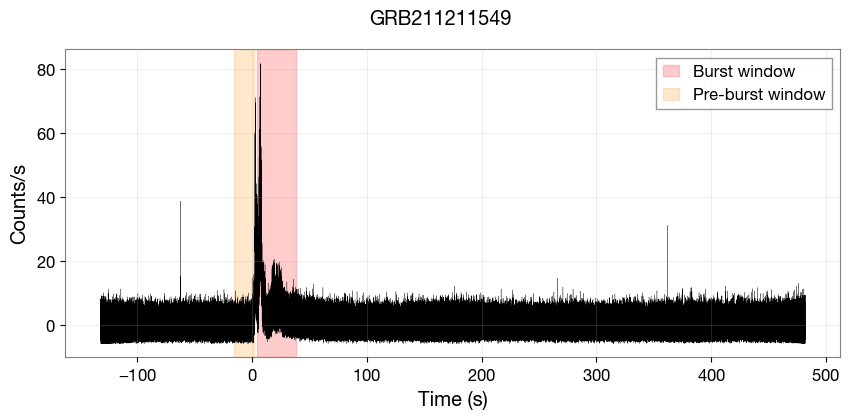

In [13]:
signal_smoothing = savgol_filter(np.clip(signal, 0, None), max(3, int(1/Tbin)|1), 1)
peak_time = time[np.argmax(signal_smoothing)]
T5 = peak_time - (0.1*Cataloug_T90)
T95 = T5+Cataloug_T90
t_pb_start = max(time[0], (T5 - Pre_burst_lead))
t_pb_end = T5-Pre_burst_offset

# q_transform.copy.crop
# signal_crop = crop(0,T90)
#background_crop = crop(-T90, -2) 
# not important if signal is not symmetric 

print(f"Burst:[{T5:.3f}, {T95:.3f}] seconds")
print(f"Pre-burst:[{t_pb_start:.3f}, {t_pb_end:.3f}] seconds")

fig, ax1 = plt.subplots(figsize=(10, 4))
fig.suptitle(GRB_name)
ax1.plot(time, signal, color='black', lw='0.2')
ax1.axvspan(T5, T95, color='red', alpha=0.2, label='Burst window')
ax1.axvspan(t_pb_start, t_pb_end, color='darkorange', alpha=0.2, label='Pre-burst window')
ax1.set_ylim(-10, None)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Counts/s')
ax1.legend()
ax1.grid(alpha=0.3)
plt.savefig(f'{GRB_name}_lightcurve.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Q-transform

In [14]:
f_low = max(0.1, 1 / (5.0*Cataloug_T90))
f_high = min((fs*0.45), 1 / (2 * Tbin))
fres = (f_high-f_low) / 200
start = float(time[0])

ts = TimeSeries(np.nan_to_num(signal), sample_rate=fs, t0=start, unit='ct/s')
outseg = Segment(max(start, t_pb_start), min(time[-1], T95 + 5.0))

QT = ts.q_transform(qrange=(Q_fixed, Q_fixed), frange=(f_low, f_high), outseg=outseg, norm='median', whiten=False, fres=fres)
QT = ts.q_transform(qrange=(30, 60), frange=(f_low, f_high), outseg=outseg, norm='median', whiten=False, fres=fres)
print(QT.q)

t_QT = QT.times.value
f_QT = QT.frequencies.value
E = QT.value

print(f"Q-transform: \nShape of energy tiles:{E.shape} \nQ = {Q_fixed}  \nFrequency Range = [{f_QT[0]:.3f}, {f_QT[-1]:.3f}] Hz")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gwpy/signal/qtransform.py:879: UserWarning: upper frequency of 900.0 Hz is too high for the given Q range, resetting to 750.9410347915281 Hz
  return QTiling(


42.426406871192846
Q-transform: 
Shape of energy tiles:(1000, 200) 
Q = 10  
Frequency Range = [0.100, 895.501] Hz


# KS test

In [15]:
burst_mask = (t_QT>=T5)&(t_QT<=T95)
preburst_mask = (t_QT>=t_pb_start)&(t_QT<t_pb_end)
ks_pval = np.full(len(f_QT),np.nan)
ks_D = np.full(len(f_QT),np.nan)

print(f"Number of burst tiles: {burst_mask.sum()}")
print(f"Number of pre-burst tiles: {preburst_mask.sum()}")

for i, _ in enumerate(f_QT):
    pre_burst = E[preburst_mask,i]
    pre_burst = pre_burst[np.isfinite(pre_burst)]
    burst = E[burst_mask,i]
    burst = burst[np.isfinite(burst)]
    if len(pre_burst) < 4 or len(burst) < 4:
        continue
    ks_D[i], ks_pval[i] = ks_2samp(burst, pre_burst, alternative='greater')

Number of burst tiles: 578
Number of pre-burst tiles: 304


# MVT extraction

In [6]:
significant_bins= np.where((np.isfinite(ks_pval) & (ks_pval<P_threshold)))[0]
                           
if len(significant_bins) == 0:
    print(f"There's no significant points at p<{P_threshold}, raise the threshold for p!")
else:
    exclude = 1
    for i in range(len(f_QT)-1, 0, -1):
        if ks_D[i] - ks_D[i-1] < 1e-4 :
            exclude+=1
        else:
            break
    safe_bins=significant_bins[significant_bins<len(f_QT)-exclude]
    sig_diff = np.diff(safe_bins)
    big_gaps = np.where(sig_diff>5)[0]
    
    if len(big_gaps)>0:
        main_cluster = safe_bins[:big_gaps[-1]+1] # everything before the first big gap
    else:
        main_cluster = safe_bins    
    
    best_bin = main_cluster.max()
    f_max = f_QT[best_bin]
    tau_1 = 1/f_max 
    tau_2 = Q_fixed / (2*np.pi*f_max)
    tau_ms = 1000/f_QT
    
    print(f"Size of the main cluster: {len(main_cluster)} frequency bins")
    print(f"Highest significant variability frequency: {f_max:.3f}Hz (bin {best_bin}/{len(f_QT)})")
    print(f"MVT with (1/f) = {tau_1*1e3:.2f}ms ({tau_1/Cataloug_tau_beta:.2f}x catalog value)")
    print(f"MVT with (Q/2*pi*f) = {tau_2*1e3:.2f}ms ({tau_2/Cataloug_tau_beta:.2f}x catalog value)")

Size of the main cluster: 1 frequency bins
Highest significant variability frequency: 0.100Hz (bin 0/200)
MVT with (1/f) = 10000.00ms (4000.00x catalog value)
MVT with (Q/2*pi*f) = 15915.49ms (6366.20x catalog value)


# Diagnostic Plot 

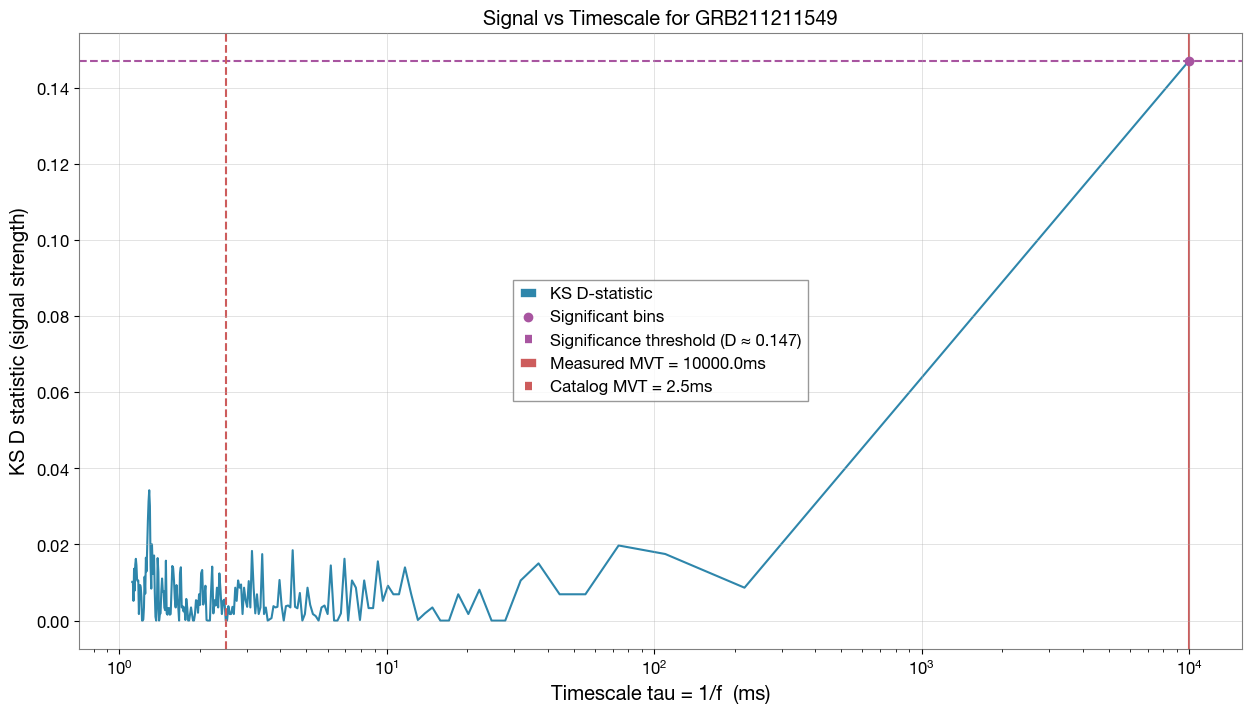

In [7]:
fig,ax = plt.subplots(figsize=(15,8))

valid_ks = np.isfinite(ks_D)
ax.plot(tau_ms[valid_ks], ks_D[valid_ks], color='#2e86ab')

significant_points = np.isfinite(ks_pval)&(ks_pval < P_threshold)
ax.scatter(tau_ms[significant_points], ks_D[significant_points], color='#a855a0', zorder=3)

D_threshold = ks_D[significant_points].min()
ax.axhline(D_threshold, color='#a855a0', lw=1.5, ls='--')

measured_tau = 1000/f_max
ax.axvline(measured_tau, color='#cd5c5c', ls='-')

tau_catalog_ms = Cataloug_tau_beta*1e3
ax.axvline(tau_catalog_ms, color='#cd5c5c', ls='--')

ax.set_title(f'Signal vs Timescale for {GRB_name}')
custom_lines = [ax.lines[0], ax.collections[0],
    Line2D([0], [0], color='#a855a0', lw=1.5, ls='--'),
    Line2D([0], [0], color='#cd5c5c', lw=1.5, ls='-'),
    Line2D([0], [0], color='#cd5c5c', lw=1.5, ls='--'),]
custom_labels = ['KS D-statistic','Significant bins',
    f'Significance threshold (D ≈ {D_threshold:.3f})',
    f'Measured MVT = {measured_tau:.1f}ms',
    f'Catalog MVT = {tau_catalog_ms:.1f}ms',]
ax.legend(custom_lines, custom_labels)
ax.set_xlabel('Timescale tau = 1/f  (ms)')
ax.set_xscale('log')
ax.set_ylabel('KS D statistic (signal strength)')
ax.grid(alpha=0.5)
plt.savefig(f'{GRB_name}_diagnostic.pdf', bbox_inches='tight', dpi=300)

In [8]:
print(f"GRB: {GRB_name}")
print(f"T90: {Cataloug_T90:.3f} (s)")
print(f"\nCluster data:")
print(f"  Main cluster size: {len(main_cluster)} frequency bins")
print(f"  Edge bins excluded: {exclude}")
print(f"  f_max:{f_max:.3f} Hz (bin {best_bin}/{len(f_QT)})")
print(f"\nMVT:")
print(f"  Calculated MVT with 1/f:{tau_1*1e3:.1f} ms")
print(f"  Calcluated MVT with Q/2*pi*f:{tau_2*1e3:.1f} ms")
print(f"  Catalog MVT: {Cataloug_tau_beta*1e3:.1f} ms")
print(f"  Difference (1/f): {(tau_1 - Cataloug_tau_beta)*1e3:+.1f} ms")
print(f"  Ratio (1/f): {tau_1/Cataloug_tau_beta:.2f}×")
print(f"  Ratio (Q/2*pi*f: {tau_2/Cataloug_tau_beta:.2f}x")
print(f"\nOther Data:")
print(f"  Q value: {Q_fixed}")
print(f"  Tbin: {Tbin*1e3:.1f} ms")
print(f"  N: {len(signal)} samples")
print(f"  Burst tiles: {burst_mask.sum()}")
print(f"  Pre-burst tiles: {preburst_mask.sum()}")
print(
        f"{GRB_name}, "
        f"{Cataloug_T90:.3f}, "
        f"{len(main_cluster)}, "
        f"{exclude}, "
        f"{f_max:.3f}, "
        f"{best_bin}/{len(f_QT)}, "
        f"{tau_1*1e3:.1f}, "
        f"{tau_2*1e3:.1f}, "
        f"{Cataloug_tau_beta*1e3:.1f}, "
        f"{(tau_1-Cataloug_tau_beta)*1e3:+.1f}, "
        f"{tau_1/Cataloug_tau_beta:.2f}, "
        f"{tau_2/Cataloug_tau_beta:.2f}, "
        f"{Q_fixed}, "
        f"{Tbin*1e3:.1f}, "
        f"{len(signal)}, "
        f"{burst_mask.sum()}, "
        f"{preburst_mask.sum()}"
)

GRB: GRB211211549
T90: 34.305 (s)

Cluster data:
  Main cluster size: 1 frequency bins
  Edge bins excluded: 2
  f_max:0.100 Hz (bin 0/200)

MVT:
  Calculated MVT with 1/f:10000.0 ms
  Calcluated MVT with Q/2*pi*f:15915.5 ms
  Catalog MVT: 2.5 ms
  Difference (1/f): +9997.5 ms
  Ratio (1/f): 4000.00×
  Ratio (Q/2*pi*f: 6366.20x

Other Data:
  Q value: 10
  Tbin: 0.5 ms
  N: 1227999 samples
  Burst tiles: 578
  Pre-burst tiles: 304
GRB211211549, 34.305, 1, 2, 0.100, 0/200, 10000.0, 15915.5, 2.5, +9997.5, 4000.00, 6366.20, 10, 0.5, 1227999, 578, 304


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gwpy/plot/plot.py:349: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  super().show(warn=warn)


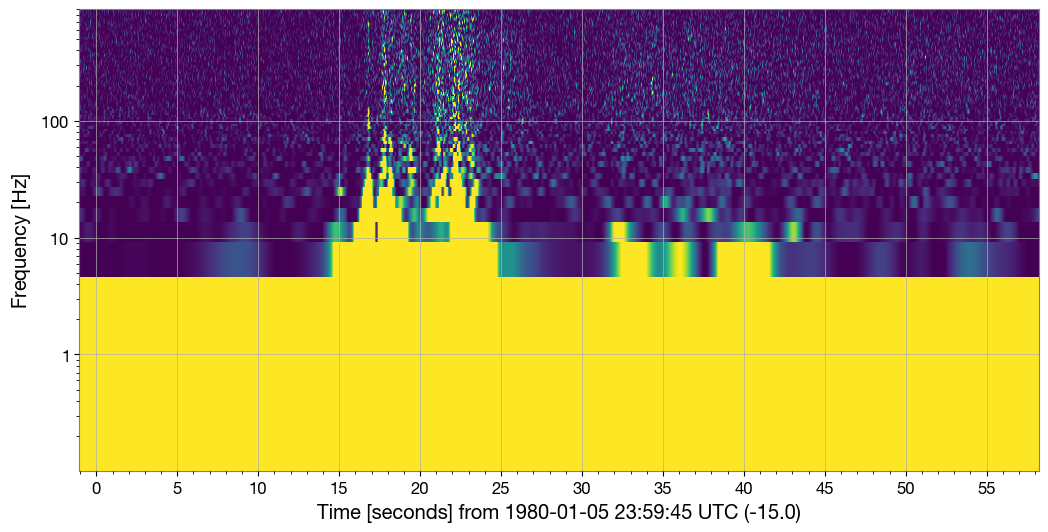

In [9]:
plot = QT.plot(yscale='log', vmin=0.5, vmax=25)
plt.savefig(f'{GRB_name}_spectrogram.pdf', bbox_inches='tight', dpi=300)
plot.show()

# Diagnostic table

In [12]:
print(f"\n{'Bin':>4}  {'Frequency (Hz)':>14}  {'MVT (ms)':>9}  {'D statistic':>11}  {'p-value':>10}  Significance")
for i in range(len(f_QT)):
    if np.isfinite(ks_pval[i]) and ks_pval[i] < P_threshold:
        flag = "!!!"
    else:
        flag = ""

    if np.isfinite(ks_D[i]):
        d = f"{ks_D[i]:.3f}"
    else:
        d = "N/A"

    if np.isfinite(ks_pval[i]):
        pv = f"{ks_pval[i]:.3e}"
    else:
        pv = "N/A"

    print(f"{i:>4}  {f_QT[i]:>14.4f}  {1000/f_QT[i]:>9.1f}  {d:>11}  {pv:>10}  {flag}")


 Bin  Frequency (Hz)   MVT (ms)  D statistic     p-value  Significance
   0          0.1000    10000.0        0.000   1.000e+00  
   1          0.3245     3081.7        0.000   1.000e+00  
   2          0.5490     1821.5        0.348   1.330e-18  !!!
   3          0.7735     1292.8        0.130   3.417e-03  !!!
   4          0.9980     1002.0        0.248   9.714e-10  !!!
   5          1.2225      818.0        0.466   1.941e-33  !!!
   6          1.4470      691.1        0.334   3.854e-17  !!!
   7          1.6715      598.3        0.040   5.656e-01  
   8          1.8960      527.4        0.086   8.305e-02  
   9          2.1205      471.6        0.004   9.898e-01  
  10          2.3450      426.4        0.387   5.976e-23  !!!
  11          2.5695      389.2        0.499   2.119e-38  !!!
  12          2.7940      357.9        0.355   2.183e-19  !!!
  13          3.0185      331.3        0.068   2.074e-01  
  14          3.2430      308.4        0.010   9.583e-01  
  15          3.467

In [18]:
if len(significant_bins) == 0:
    print(f"There's no significant points at p<{P_threshold}, raise the threshold for p!")
else:
    sig_diff = np.diff(significant_bins)
    big_gaps = np.where(sig_diff>5)[0]
    
    if len(big_gaps)>0:
        main_cluster = significant_bins[big_gaps[-1]+1:] # everything before the first big gap
    else:
        main_cluster = significant_bins    
    best_bin = main_cluster.max()
    f_max = f_QT[best_bin]
    tau_1 = 1/f_max 
    tau_2 = Q_fixed / (2*np.pi*f_max)
    tau_ms = 1000/f_QT
    
    print(f"Size of the main cluster: {len(main_cluster)} frequency bins")
    print(f"Highest significant variability frequency: {f_max:.3f}Hz (bin {best_bin}/{len(f_QT)})")
    print(f"MVT with (1/f) = {tau_1*1e3:.2f}ms ({tau_1/Cataloug_tau_beta:.2f}x catalog value)")
    print(f"MVT with (Q/2*pi*f) = {tau_2*1e3:.2f}ms ({tau_2/Cataloug_tau_beta:.2f}x catalog value)")

Size of the main cluster: 38 frequency bins
Highest significant variability frequency: 44.776Hz (bin 199/200)
MVT with (1/f) = 22.33ms (0.12x catalog value)
MVT with (Q/2*pi*f) = 35.55ms (0.19x catalog value)
